# Banister Fitness-Fatigue Model — Prototype

This notebook implements the core Banister model from `/design/math_model.md`.

**Goal:** Fit the model to personal training data and verify that predicted performance tracks actual PRs.

---

## Step 1 — Import libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# TODO: implement Banister update function
# TODO: load personal training data from CSV
# TODO: plot fitness, fatigue, and performance curves

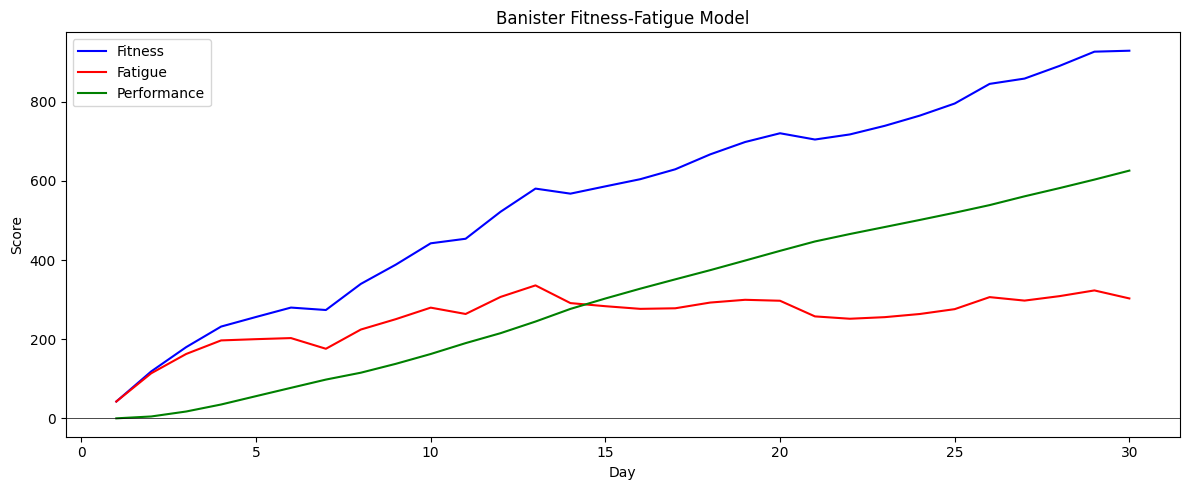

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── Banister Model Parameters ──────────────────────────────────────
tau_fitness  = 45   # fitness decay constant (days)
tau_fatigue  = 7    # fatigue decay constant (days)

# ── Banister Update Function ───────────────────────────────────────
def update_banister(fitness_prev, fatigue_prev, trimp):
    fitness  = fitness_prev  * np.exp(-1 / tau_fitness)  + trimp
    fatigue  = fatigue_prev  * np.exp(-1 / tau_fatigue)  + trimp
    performance = fitness - fatigue
    return fitness, fatigue, performance

# ── Test with 30 days of fake training data ────────────────────────
np.random.seed(42)
trimps = np.random.uniform(20, 80, 30)  # random daily loads
trimps[6]  = 0   # rest day week 1
trimps[13] = 0   # rest day week 2
trimps[20] = 0   # rest day week 3

fitness, fatigue, performance = 0, 0, 0
history = []

for day, trimp in enumerate(trimps):
    fitness, fatigue, performance = update_banister(fitness, fatigue, trimp)
    history.append({
        "day": day + 1,
        "trimp": trimp,
        "fitness": fitness,
        "fatigue": fatigue,
        "performance": performance
    })

df = pd.DataFrame(history)

# ── Plot ───────────────────────────────────────────────────────────
plt.figure(figsize=(12, 5))
plt.plot(df["day"], df["fitness"],     label="Fitness",     color="blue")
plt.plot(df["day"], df["fatigue"],     label="Fatigue",     color="red")
plt.plot(df["day"], df["performance"], label="Performance", color="green")
plt.axhline(0, color="black", linewidth=0.5)
plt.xlabel("Day")
plt.ylabel("Score")
plt.title("Banister Fitness-Fatigue Model")
plt.legend()
plt.tight_layout()
plt.show()

In [4]:
import pandas as pd

df_raw = pd.read_csv('../strong_workouts.csv')
print(df_raw.columns.tolist())
print(df_raw.head())

['Date', 'Workout Name', 'Duration', 'Exercise Name', 'Set Order', 'Weight', 'Reps', 'Distance', 'Seconds', 'RPE']
                  Date Workout Name Duration    Exercise Name Set Order  \
0  2020-06-23 11:58:22      Leg Day      34m         Box Jump         1   
1  2020-06-23 11:58:22      Leg Day      34m         Box Jump         2   
2  2020-06-23 11:58:22      Leg Day      34m         Box Jump         3   
3  2020-06-23 11:58:22      Leg Day      34m  Deadlift (Band)         1   
4  2020-06-23 11:58:22      Leg Day      34m  Deadlift (Band)         2   

   Weight  Reps  Distance  Seconds  RPE  
0     0.0  10.0       0.0      0.0  NaN  
1     0.0  10.0       0.0      0.0  NaN  
2     0.0  10.0       0.0      0.0  NaN  
3    25.0  10.0       0.0      0.0  NaN  
4    25.0  10.0       0.0      0.0  NaN  


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── Load and clean data ────────────────────────────────────────────
df = pd.read_csv('../strong_workouts.csv')
df['Date'] = pd.to_datetime(df['Date']).dt.date
df = df[df['Weight'] > 0].copy()  # remove bodyweight/zero weight sets

# ── Epley 1RM estimate per set ─────────────────────────────────────
df['estimated_1rm'] = df['Weight'] * (1 + df['Reps'] / 30)

# ── Rolling max 1RM per exercise (best estimate so far) ───────────
df = df.sort_values('Date')
df['max_1rm'] = df.groupby('Exercise Name')['estimated_1rm'].cummax()

# ── Intensity % and TRIMP per set ─────────────────────────────────
df['intensity'] = df['Weight'] / df['max_1rm']
df['trimp_set'] = df['Weight'] * df['Reps'] * (df['intensity'] ** 2)

# ── Sum TRIMP per day ──────────────────────────────────────────────
daily_trimp = df.groupby('Date')['trimp_set'].sum().reset_index()
daily_trimp.columns = ['date', 'trimp']
daily_trimp = daily_trimp.sort_values('date')

print(daily_trimp.head(10))
print(f"\nTotal sessions: {len(daily_trimp)}")
print(f"Date range: {daily_trimp['date'].min()} → {daily_trimp['date'].max()}")

         date        trimp
0  2020-06-23  1598.958333
1  2020-08-25  2475.000000
2  2020-08-28  2693.129463
3  2020-08-31  2879.081633
4  2020-09-03  5243.561795
5  2020-09-04  3681.505102
6  2020-09-28  1719.914283
7  2021-01-02  1858.559211
8  2021-01-09  1672.960466
9  2021-01-11  3630.355626

Total sessions: 751
Date range: 2020-06-23 → 2026-03-04


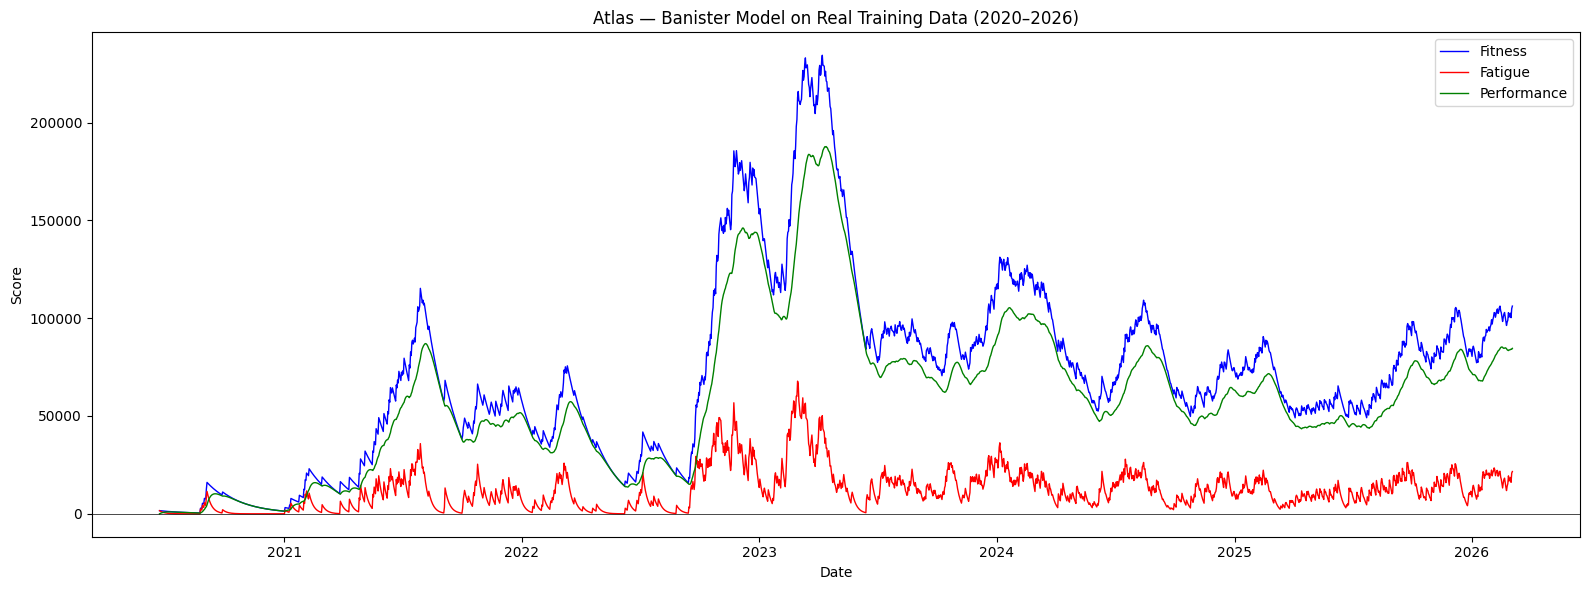

In [6]:
# ── Fill in every calendar day (rest days = 0 TRIMP) ──────────────
all_dates = pd.date_range(daily_trimp['date'].min(), daily_trimp['date'].max())
daily_trimp['date'] = pd.to_datetime(daily_trimp['date'])
daily_trimp = daily_trimp.set_index('date').reindex(all_dates, fill_value=0).reset_index()
daily_trimp.columns = ['date', 'trimp']

# ── Banister parameters ────────────────────────────────────────────
tau_fitness = 45
tau_fatigue = 7

# ── Run the model over every day ───────────────────────────────────
fitness, fatigue = 0, 0
records = []

for _, row in daily_trimp.iterrows():
    fitness  = fitness  * np.exp(-1 / tau_fitness) + row['trimp']
    fatigue  = fatigue  * np.exp(-1 / tau_fatigue) + row['trimp']
    performance = fitness - fatigue
    records.append({
        'date':        row['date'],
        'trimp':       row['trimp'],
        'fitness':     fitness,
        'fatigue':     fatigue,
        'performance': performance
    })

results = pd.DataFrame(records)

# ── Plot ───────────────────────────────────────────────────────────
plt.figure(figsize=(16, 6))
plt.plot(results['date'], results['fitness'],     label='Fitness',     color='blue',  linewidth=1)
plt.plot(results['date'], results['fatigue'],     label='Fatigue',     color='red',   linewidth=1)
plt.plot(results['date'], results['performance'], label='Performance', color='green', linewidth=1)
plt.axhline(0, color='black', linewidth=0.5)
plt.xlabel('Date')
plt.ylabel('Score')
plt.title('Atlas — Banister Model on Real Training Data (2020–2026)')
plt.legend()
plt.tight_layout()
plt.show()